 ## COVID-19 detection- Healthcare
### 1. Covid 19 Detection using X-Ray Images by implementing effective deep learning technique.
### Problem Statement : Detect to find if the patient has been diagnosed with COVID or not using X-Ray Images by implementing out effective deep learning techniques to the dataset.
#### DataSet:https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database

#### **Step-1(loading the Data)**

In [ ]:
#loading the dataset into the google colab

In [ ]:
#connection between the google colab and and kaddle dataset
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
#Downloading the Dataset into colab
!kaggle datasets download -d tawsifurrahman/covid19-radiography-database

Dataset URL: https://www.kaggle.com/datasets/tawsifurrahman/covid19-radiography-database
License(s): copyright-authors
 92% 715M/778M [00:07<00:01, 41.2MB/s]
100% 778M/778M [00:07<00:00, 114MB/s] 


In [ ]:
#Unzipping the file
!unzip covid19-radiography-database.zip

Streaming output truncated to the last 5000 lines.
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7921.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7922.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7923.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7924.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7925.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7926.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7927.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7928.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7929.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-793.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7930.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7931.png  
  inflating: COVID-19_Radiography_Dataset/Normal/masks/Normal-7932.png  
 

#### **Step-2(Reading the Data)**

In [ ]:
#Dividing the folders based on the data
mainfolder = 'COVID-19_Radiography_Dataset'
subfolders = ["COVID","Lung_Opacity","Normal","Viral Pneumonia"]

In [ ]:
#Displaying the mask folders in the given data'
key = '/masks'
for f in [mainfolder+'/'+i+key for i in subfolders]:
  print(f)

COVID-19_Radiography_Dataset/COVID/masks
COVID-19_Radiography_Dataset/Lung_Opacity/masks
COVID-19_Radiography_Dataset/Normal/masks
COVID-19_Radiography_Dataset/Viral Pneumonia/masks


In [ ]:
#Deleting the mask folder in the each
import os,shutil
import numpy as np,pandas as pd
for f in [mainfolder+'/'+i+key for i in subfolders]:
  if os.path.exists(f):
    shutil.rmtree(f)
    print("Deleted Folders:",f)
  else:
    print("Folder not Found")

Deleted Folders: COVID-19_Radiography_Dataset/COVID/masks
Deleted Folders: COVID-19_Radiography_Dataset/Lung_Opacity/masks
Deleted Folders: COVID-19_Radiography_Dataset/Normal/masks
Deleted Folders: COVID-19_Radiography_Dataset/Viral Pneumonia/masks


In [ ]:
#Reading the images and storing as arrays
import tensorflow as tf
data = tf.keras.preprocessing.image_dataset_from_directory(mainfolder,
                                                           labels='inferred',
                                                           label_mode='categorical',
                                                           batch_size=32)

Found 21165 files belonging to 4 classes.


In [ ]:
#Displaying the number of images in each batch
len(data)

662

In [ ]:
#Displaying the class names
data.class_names

['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']

#### Displaying the First Batch image Properties

In [ ]:
data.take(1)

<_TakeDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [ ]:
#Displaying the shape and labels of th eimages of first batch
for img,lab in data.take(1):
  print("The Images Shape is",img.shape)
  print("The Labels Shape is",lab.shape)
  print("Labels are:",lab)

The Images Shape is (32, 256, 256, 3)
The Labels Shape is (32, 4)
Labels are: tf.Tensor(
[[0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]], shape=(32, 4), dtype=float32)


#### **Reading the data of Metafiles**

In [ ]:
#Defining the path and the meta files and the data files in the two lists
path = 'COVID-19_Radiography_Dataset/'
fnames = ['COVID.metadata.xlsx','Lung_Opacity.metadata.xlsx','Normal.metadata.xlsx','Viral Pneumonia.metadata.xlsx']
dnames = ['COVID','Lung_Opacity','Normal','Viral Pneumonia']

In [ ]:
#defining an empty dictionary to store the data
d = {}
for i,j in zip(fnames,dnames):
  d[j] = pd.read_excel(path+i)
len(d)

4

In [ ]:
#Displaying the first five columns in the each data files
import pandas as pd,numpy as np
for i,j in d.items():
  print(i)
  display(j.head())

COVID


,FILE NAME,FORMAT,SIZE,URL
0,COVID-1,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
1,COVID-2,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
2,COVID-3,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
3,COVID-4,PNG,256*256,https://sirm.org/category/senza-categoria/covi...
4,COVID-5,PNG,256*256,https://sirm.org/category/senza-categoria/covi...


Lung_Opacity


,FILE NAME,FORMAT,SIZE,URL
0,Lung_Opacity-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,Lung_Opacity-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
2,Lung_Opacity-3,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
3,Lung_Opacity-4,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
4,Lung_Opacity-5,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...


Normal


,FILE NAME,FORMAT,SIZE,URL
0,NORMAL-1,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
1,NORMAL-2,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
2,NORMAL-3,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
3,NORMAL-4,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...
4,NORMAL-5,PNG,256*256,https://www.kaggle.com/c/rsna-pneumonia-detect...


Viral Pneumonia


,FILE NAME,FORMAT,SIZE,URL
0,Viral Pneumonia-1,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
1,Viral Pneumonia-2,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
2,Viral Pneumonia-3,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
3,Viral Pneumonia-4,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...
4,Viral Pneumonia-5,PNG,256*256,https://www.kaggle.com/paultimothymooney/chest...


In [ ]:
#Displaying the Total Number of Images and the Shape of images
#Counting the total images
tot = 0
for i,j in d.items():
  print(i,j.shape)
  tot += j.shape[0]
print("Total Images:",tot)

COVID (3616, 4)
Lung_Opacity (6012, 4)
Normal (10192, 4)
Viral Pneumonia (1345, 4)
Total Images: 21165


#### **Step-3(Exploratory Data Analysis)**

In [ ]:
#Displaying the maximum labels in the class
class_lab = np.argmax(lab,1)
class_lab

array([3, 1, 2, 1, 0, 2, 1, 2, 1, 0, 0, 1, 1, 1, 1, 0, 0, 2, 2, 1, 0, 1,
       0, 1, 2, 2, 3, 1, 0, 2, 2, 2])

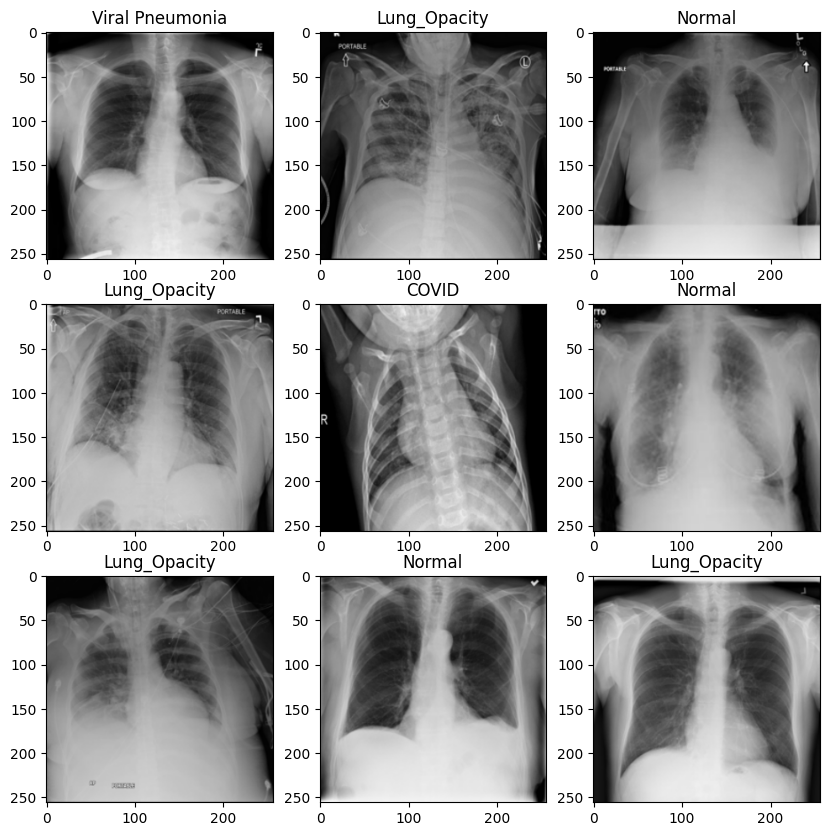

In [ ]:
#Displaying the images
import matplotlib.pyplot as pt
for img,lab in data.take(1):
  pt.figure(figsize=(10,10))
  for i in range(9):
    pt.subplot(3,3,i+1)
    pt.imshow(img[i].numpy().astype("uint8"))
    pt.title(data.class_names[class_lab[i]])

In [ ]:
#Extracting the class names and the number of images from dictionary(d)
class_n = d.keys()
images_n = [i.shape[0] for i in d.values()]
print(class_n)
print(images_n)

dict_keys(['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia'])
[3616, 6012, 10192, 1345]


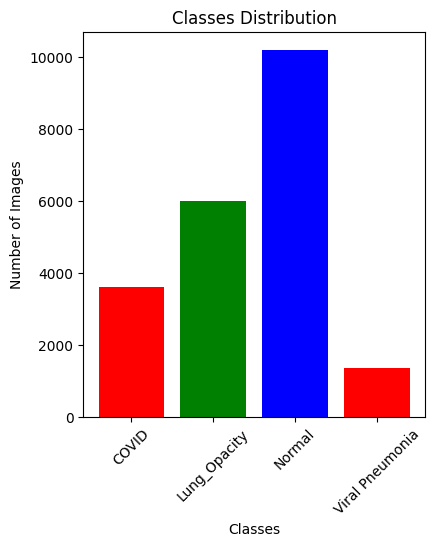

In [ ]:
import matplotlib.pyplot as pt
pt.figure(figsize=(15, 5))
# Plot 1: Class distribution
pt.subplot(1, 3, 1)
pt.bar(class_n,images_n,color=['red','green','blue'])
pt.title('Classes Distribution')
pt.xlabel('Classes')
pt.ylabel('Number of Images')
pt.xticks(rotation=45)
pt.show()

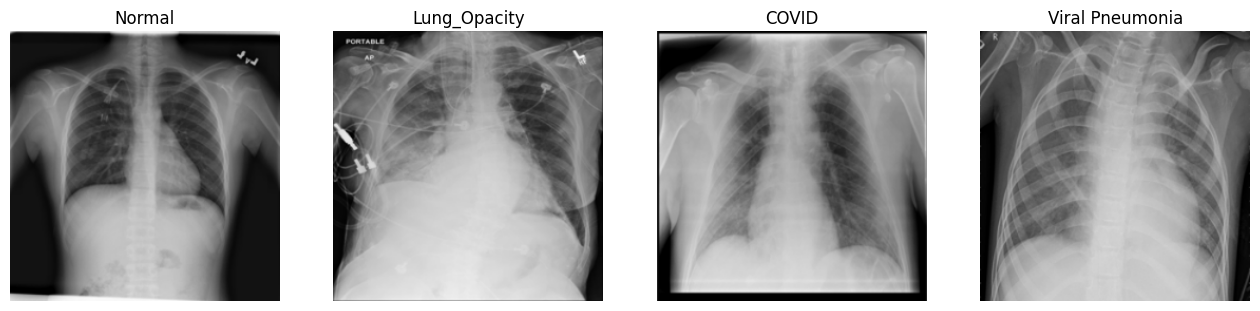

In [ ]:
# Displaying one image per class side by side
import matplotlib.pyplot as pt
import numpy as np
for img, lab in data.take(1):
    #Converting Labels to Class Index
    class_lab = np.argmax(lab,axis=1)
    #Tracking the Unique Classes Without Repetion
    shown_classes = []
    pt.figure(figsize=(16, 4))
    pos = 1
    for j in range(len(class_lab)):
        cls_name = data.class_names[class_lab[j]]
        #Avoids Duplicate(repeated) Classes
        if cls_name not in shown_classes:
            pt.subplot(1,4,pos)
            pt.imshow(img[j].numpy().astype("uint8"))
            pt.title(cls_name)
            pt.axis('off')
            shown_classes.append(cls_name)
            pos += 1
        #Stoping After the displaying the four classes
        if len(shown_classes) == 4:
            break
pt.show()

#### **Step-4(Spliting the Data)**

In [ ]:
df = pd.DataFrame({
    'image': ['COVID-19_Radiography_Dataset/COVID/images', 'COVID-19_Radiography_Dataset/Lung_Opacity/images','COVID-19_Radiography_Dataset/Normal/images','COVID-19_Radiography_Dataset/Viral Pneumonia/images'],
    'label': ['COVID','Lung_Opacity','Normal','Viral Pneumonia']
})


In [ ]:
#Spliting the data
import os
import pandas as pd
#Storing all the class names into one variable
class_n = data.class_names
#Extracting all images and labels from data
#Initializing the two empty lists to store the images and labels
image_file_paths = []
image_labels = []
for idx,row in df.iterrows():
    folder = row['image']  # folder path with images
    label = row['label']
    # List all image files inside this folder
    for file_name in os.listdir(folder):
        if file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_file_paths.append(os.path.join(folder,file_name))
            image_labels.append(label)

In [ ]:
#Creating the new DataFrame to store images and their labels
df = pd.DataFrame({'image': image_file_paths,'label': image_labels})
#Displaying the first five rows
print(df.head())

                                               image  label
0  COVID-19_Radiography_Dataset/COVID/images/COVI...  COVID
1  COVID-19_Radiography_Dataset/COVID/images/COVI...  COVID
2  COVID-19_Radiography_Dataset/COVID/images/COVI...  COVID
3  COVID-19_Radiography_Dataset/COVID/images/COVI...  COVID
4  COVID-19_Radiography_Dataset/COVID/images/COVI...  COVID


In [ ]:
#Displaying the count of labels
print(df['label'].value_counts())

label
Normal             10192
Lung_Opacity        6012
COVID               3616
Viral Pneumonia     1345
Name: count, dtype: int64


In [ ]:
#Encoding the class labels
label_mapping = {class_name: i for i, class_name in enumerate(class_n)}
df['label_encoded'] = df['label'].map(label_mapping)
#Displaying the Labels
print("Label mapping:", label_mapping)

Label mapping: {'COVID': 0, 'Lung_Opacity': 1, 'Normal': 2, 'Viral Pneumonia': 3}


In [ ]:
#Importing the modules for spliting the data
from sklearn.model_selection import train_test_split
#First, spliting the data into train and temp that is validation + test
train_df,temp_df = train_test_split(df,test_size=0.3,stratify=df['label'],random_state=50)
#Then split temp into validation and test
val_df,test_df = train_test_split(temp_df,test_size=0.5,stratify=temp_df['label'],random_state=50)
print(f"Train size:{len(train_df)}")
print(f"Validation size:{len(val_df)}")
print(f"Test size:{len(test_df)}")

Train size:14815
Validation size:3175
Test size:3175


In [ ]:
#Importing the Data Generators for the loading the Images
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_gen = ImageDataGenerator(rescale=1./255,rotation_range=15,zoom_range=0.1,horizontal_flip=True)
val_gen = ImageDataGenerator(rescale=1./255)
train_flow = train_gen.flow_from_dataframe(train_df,x_col='image',y_col='label',target_size=(128,128),class_mode='categorical',batch_size=16)
val_flow = val_gen.flow_from_dataframe(val_df,x_col='image',y_col='label',target_size=(128,128),class_mode='categorical',batch_size=16)


Found 14815 validated image filenames belonging to 4 classes.
Found 3175 validated image filenames belonging to 4 classes.


#### **Step-5(Buiding the CNN Model)**

In [ ]:
#Importing the modules for building the CNN Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(train_flow.class_indices),activation='softmax')])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
#Displaying the summary of the model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

####  **Step-6(Training the Model)**

In [ ]:
#Fitting the Model
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)
history = model.fit(train_flow,epochs=3,validation_data=val_flow,callbacks=[early_stop])

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
926/926 ━━━━━━━━━━━━━━━━━━━━ 465s 500ms/step - accuracy: 0.5658 - loss: 1.0654 - val_accuracy: 0.7137 - val_loss: 0.6765
Epoch 2/3
926/926 ━━━━━━━━━━━━━━━━━━━━ 498s 496ms/step - accuracy: 0.6822 - loss: 0.7703 - val_accuracy: 0.7490 - val_loss: 0.6164
Epoch 3/3
926/926 ━━━━━━━━━━━━━━━━━━━━ 453s 489ms/step - accuracy: 0.7113 - loss: 0.7113 - val_accuracy: 0.7562 - val_loss: 0.5873


#### **Step-7(Model Evaluation)**

In [ ]:
import tensorflow as tf
tf.config.run_functions_eagerly(True)

In [ ]:
#Displaying the Model Evaluation
#Re-enable for performance afterward
tf.config.run_functions_eagerly(True)
test_gen = ImageDataGenerator(rescale=1./255).flow_from_dataframe(test_df,x_col='image',y_col='label',target_size=(128,128),class_mode='categorical',batch_size=16,shuffle=False)
results = model.evaluate(test_gen)
print(f"Test Loss: {round(results[0],3)}, Test Accuracy: {round(results[1],3)}")
tf.config.run_functions_eagerly(False)


Found 3175 validated image filenames belonging to 4 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
/usr/local/lib/python3.12/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


199/199 ━━━━━━━━━━━━━━━━━━━━ 31s 155ms/step - accuracy: 0.7554 - loss: 0.6095
Test Loss: 0.609, Test Accuracy: 0.757


In [ ]:
#Performing the Model Predictions
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(test_gen)
y_pred_classes = np.argmax(y_pred, axis=1)
true_classes = test_gen.classes
target_names = list(test_gen.class_indices.keys())

199/199 ━━━━━━━━━━━━━━━━━━━━ 24s 123ms/step


In [ ]:
#Displaying the Classification Report
print(classification_report(true_classes, y_pred_classes, target_names=target_names))

                 precision    recall  f1-score   support

          COVID       0.87      0.33      0.48       542
   Lung_Opacity       0.77      0.71      0.74       902
         Normal       0.73      0.93      0.82      1529
Viral Pneumonia       0.87      0.82      0.84       202

       accuracy                           0.76      3175
      macro avg       0.81      0.70      0.72      3175
   weighted avg       0.77      0.76      0.74      3175



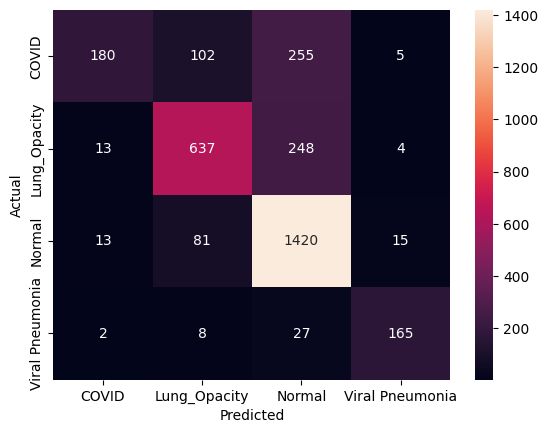

In [ ]:
#Displaying the Confusion matrix
import seaborn as sb
import matplotlib.pyplot as pt
cm = confusion_matrix(true_classes,y_pred_classes)
sb.heatmap(cm,annot=True,fmt='d',xticklabels=target_names,yticklabels=target_names)
pt.ylabel('Actual')
pt.xlabel('Predicted')
pt.show()

#### **Step-7(Conclusion)**

*   Deep learning models,particularly Convolutional Neural Networks (CNNs),have achieved very high accuracy (often above 95%) in classifying COVID-19,normal,and other types of pneumonia on publicly available X-ray datasets like the one used in this project.
*   Deep learning-based X-ray classification tools can serve as an accessible and cost-effective diagnostic aid in areas lacking advanced molecular testing facilities.
*   Studies consistently report classification accuracies of 95% or higher for detection of COVID-19 from chest X-ray images, with some models achieving up to 98%-100% accuracy under optimal conditions and proper dataset curation.
**Overall,this project demonstrates the feasibility and value of using deep learning for COVID-19 detection from X-ray images, with results that can directly benefit front-line healthcare providers and public health initiatives**